# LBA-30 results — baseline vs Option A (zero_charge) vs Option C (real_charge)

Parses the SLURM logs directly, so the numbers in this notebook are always
traceable to a job ID. No hand-transcribed metrics.

**Arms** (all: LBA-30 split, 50 epochs, batch 8, lr 1e-4, seeds 42/123/7)

| arm | node scalars | `--v3-cache` |
|---|---|---|
| `baseline` | 9 | none |
| `zero_charge` | 137 | `charge_zero` |
| `real_charge` | 137 | `charge_real` |

In [1]:
# §1 — parse the SLURM logs
import re
from pathlib import Path
import numpy as np
import pandas as pd

GVP_ROOT = Path("/net/galaxy/home/koes/skothare/gvp-pytorch")

# Add/remove logs here. Globs are fine; every matching file is parsed.
LOG_FILES = [
    GVP_ROOT / "logs" / "both_arms_56894578.out",              # baseline + zero_charge
    GVP_ROOT / "logs" / "real_charge" / "gvp_lba_realcharge_56934313.out",
]

_HDR = re.compile(r"#+\s*SEED\s+(\d+)\s*[\u2014\-]\s*(\w+)\s+(train|test)\s*#+")
_EP  = re.compile(r"EPOCH\s+(\d+)\s+(TRAIN|VAL)\s+loss:\s+([\d.]+)")
_MET = re.compile(r"^\s+(rmse|pearson_r|spearman_r|r2):\s+(-?[\d.]+)")

def parse_log(path):
    """Return (test_metrics_rows, epoch_curve_rows) from one job log.

    Arm and seed come from the '######## SEED n - arm train/test ########'
    banners the submit scripts emit, so a single file holding several arms
    (both_arms_*.out) is handled the same way as a single-arm file.
    """
    tests, curves, pending = [], [], None
    seed = arm = phase = None
    for line in Path(path).read_text().splitlines():
        h = _HDR.search(line)
        if h:
            seed, arm, phase = int(h.group(1)), h.group(2), h.group(3)
            pending = None
            continue
        e = _EP.search(line)
        if e and phase == "train":
            curves.append(dict(arm=arm, seed=seed, epoch=int(e.group(1)),
                               split=e.group(2).lower(), loss=float(e.group(3))))
            continue
        # Anchor on the banner itself. A bare 'LBA Test Metrics' substring also
        # appears in the script's closing 'Metrics: grep -A5 ...' hint line,
        # which would otherwise open an empty record full of NaNs.
        if line.strip().startswith("=== LBA Test Metrics"):
            pending = dict(arm=arm, seed=seed, source=Path(path).name)
            tests.append(pending)
            continue
        m = _MET.match(line)
        if m and pending is not None:
            pending[m.group(1)] = float(m.group(2))
    return tests, curves

all_tests, all_curves = [], []
for f in LOG_FILES:
    if not f.exists():
        print(f"MISSING: {f}")
        continue
    t, c = parse_log(f)
    all_tests += t
    all_curves += c
    print(f"{f.name}: {len(t)} test records, {len(c)} epoch rows")

tests  = pd.DataFrame(all_tests)
curves = pd.DataFrame(all_curves)

ARM_ORDER = ["baseline", "zero_charge", "real_charge"]
tests["arm"] = pd.Categorical(tests["arm"], categories=ARM_ORDER, ordered=True)
tests = tests.sort_values(["arm", "seed"]).reset_index(drop=True)

assert not tests[["rmse", "pearson_r"]].isna().any().any(), "NaN in parsed metrics"
tests

both_arms_56894578.out: 6 test records, 600 epoch rows
gvp_lba_realcharge_56934313.out: 3 test records, 300 epoch rows


,arm,seed,source,rmse,pearson_r,spearman_r,r2
0,baseline,7,both_arms_56894578.out,1.5933,0.3734,0.3635,0.1052
1,baseline,42,both_arms_56894578.out,1.4647,0.4938,0.4991,0.2438
2,baseline,123,both_arms_56894578.out,1.6445,0.2577,0.2693,0.0467
3,zero_charge,7,both_arms_56894578.out,1.6988,0.3215,0.3327,-0.0174
4,zero_charge,42,both_arms_56894578.out,1.7781,0.3340,0.3276,-0.1144
5,zero_charge,123,both_arms_56894578.out,1.7806,0.3068,0.2996,-0.1176
6,real_charge,7,gvp_lba_realcharge_56934313.out,1.6458,0.4004,0.3887,0.0452
7,real_charge,42,gvp_lba_realcharge_56934313.out,1.7362,0.3625,0.3659,-0.0625
8,real_charge,123,gvp_lba_realcharge_56934313.out,1.7237,0.2965,0.2843,-0.0473


## §2 — Summary table

`ddof=0` (population std) matches the convention used for the previously
reported numbers — baseline 1.567 ± 0.075, Option A 1.752 ± 0.038,
Pearson 0.321 ± 0.011. Using `ddof=1` would print different error bars from
the ones already circulated.

In [2]:
# §2 — mean ± std per arm
METRICS = ["rmse", "pearson_r", "spearman_r", "r2"]

summary = pd.concat(
    [tests.groupby("arm", observed=True)[METRICS].mean().add_suffix("_mean"),
     tests.groupby("arm", observed=True)[METRICS].std(ddof=0).add_suffix("_std")],
    axis=1).round(4)

pretty = pd.DataFrame({
    m: summary[f"{m}_mean"].map("{:.4f}".format) + " ± " + summary[f"{m}_std"].map("{:.4f}".format)
    for m in METRICS})
pretty.index.name = "arm"
print(pretty.to_string())

print("\n--- per-seed detail ---")
print(tests.pivot_table(index="seed", columns="arm", values="rmse", observed=True).round(4).to_string())

                        rmse        pearson_r       spearman_r                r2
arm                                                                             
baseline     1.5675 ± 0.0756  0.3750 ± 0.0964  0.3773 ± 0.0943   0.1319 ± 0.0827
zero_charge  1.7525 ± 0.0380  0.3208 ± 0.0111  0.3200 ± 0.0146  -0.0831 ± 0.0465
real_charge  1.7019 ± 0.0400  0.3531 ± 0.0429  0.3463 ± 0.0448  -0.0215 ± 0.0476

--- per-seed detail ---
arm   baseline  zero_charge  real_charge
seed                                    
7       1.5933       1.6988       1.6458
42      1.4647       1.7781       1.7362
123     1.6445       1.7806       1.7237


## §3 — Paired per-seed comparison

Arms share seeds 42/123/7, so they can be compared **paired** rather than as
independent samples. Pairing removes seed-to-seed variance from the comparison,
which matters a great deal here: baseline's RMSE std is 0.076 while the A→C
effect is 0.05, so an unpaired test on n=3 would have almost no power.

In [3]:
# §3 — paired deltas and paired t-tests
from scipy import stats

def paired(metric, arm_a, arm_b):
    """arm_b - arm_a, matched by seed. Returns (per-seed deltas, t, p)."""
    a = tests[tests.arm == arm_a].set_index("seed")[metric]
    b = tests[tests.arm == arm_b].set_index("seed")[metric]
    seeds = sorted(set(a.index) & set(b.index))
    da, db = a.loc[seeds].to_numpy(), b.loc[seeds].to_numpy()
    t, p = stats.ttest_rel(db, da)
    return pd.Series(db - da, index=seeds), t, p

for metric in ["rmse", "pearson_r"]:
    print(f"\n===== {metric} =====")
    for a, b in [("zero_charge", "real_charge"),
                 ("baseline",    "real_charge"),
                 ("baseline",    "zero_charge")]:
        d, t, p = paired(metric, a, b)
        sign = "all same direction" if (d > 0).all() or (d < 0).all() else "MIXED direction"
        print(f"{a:12s} -> {b:12s}  mean Δ={d.mean():+.4f}  "
              f"t={t:+.3f}  p={p:.4f}  [{sign}]")
        print(f"{'':28s}per seed: " +
              "  ".join(f"{s}:{v:+.4f}" for s, v in d.items()))


===== rmse =====
zero_charge  -> real_charge   mean Δ=-0.0506  t=-11.261  p=0.0078  [all same direction]
                            per seed: 7:-0.0530  42:-0.0419  123:-0.0569
baseline     -> real_charge   mean Δ=+0.1344  t=+1.948  p=0.1907  [all same direction]
                            per seed: 7:+0.0525  42:+0.2715  123:+0.0792
baseline     -> zero_charge   mean Δ=+0.1850  t=+2.855  p=0.1039  [all same direction]
                            per seed: 7:+0.1055  42:+0.3134  123:+0.1361

===== pearson_r =====
zero_charge  -> real_charge   mean Δ=+0.0324  t=+1.253  p=0.3367  [MIXED direction]
                            per seed: 7:+0.0789  42:+0.0285  123:-0.0103
baseline     -> real_charge   mean Δ=-0.0218  t=-0.398  p=0.7290  [MIXED direction]
                            per seed: 7:+0.0270  42:-0.1313  123:+0.0388
baseline     -> zero_charge   mean Δ=-0.0542  t=-0.899  p=0.4637  [MIXED direction]
                            per seed: 7:-0.0519  42:-0.1598  123:+0.0491


## §4 — Bar chart

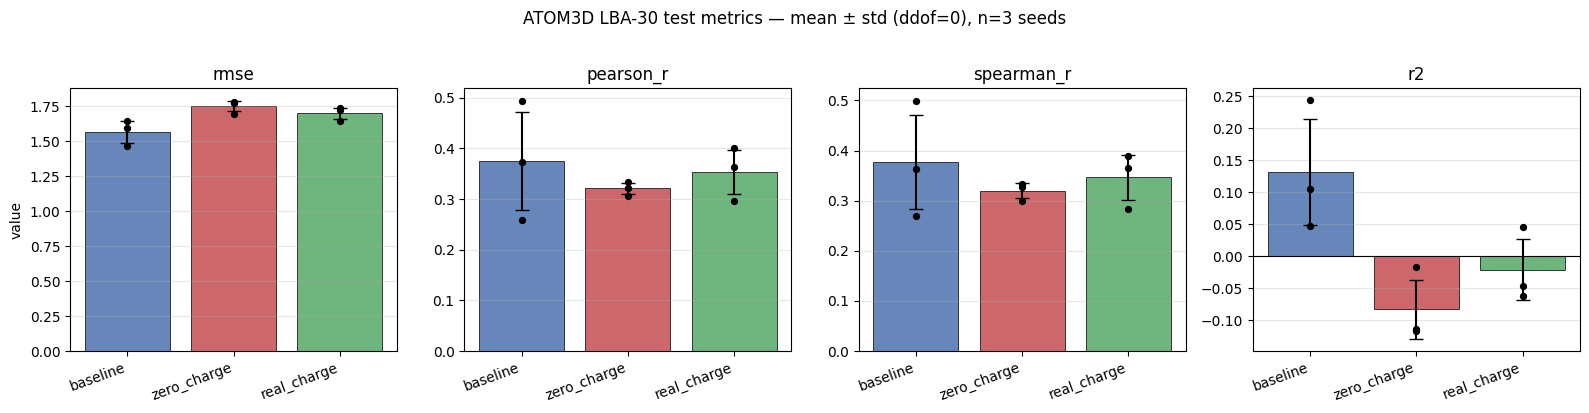

In [4]:
# §4 — mean ± std across the three arms
import matplotlib.pyplot as plt

COLORS = {"baseline": "#4C72B0", "zero_charge": "#C44E52", "real_charge": "#55A868"}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes, METRICS):
    means = summary[f"{metric}_mean"]
    stds  = summary[f"{metric}_std"]
    x = np.arange(len(means))
    ax.bar(x, means, yerr=stds, capsize=5,
           color=[COLORS[a] for a in means.index], alpha=0.85,
           edgecolor="black", linewidth=0.6)
    # Individual seeds on top of the bar: with n=3, the spread of the raw
    # points is more informative than the error bar alone.
    for i, arm in enumerate(means.index):
        pts = tests[tests.arm == arm][metric]
        ax.scatter(np.full(len(pts), i), pts, color="black", zorder=3, s=18)
    ax.set_xticks(x)
    ax.set_xticklabels(means.index, rotation=20, ha="right")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)
    if metric == "r2":
        ax.axhline(0, color="black", lw=0.8)

axes[0].set_ylabel("value")
fig.suptitle("ATOM3D LBA-30 test metrics — mean ± std (ddof=0), n=3 seeds", y=1.02)
plt.tight_layout()
plt.show()

label variance — probe: ['2.8368']  GVP: 2.8371


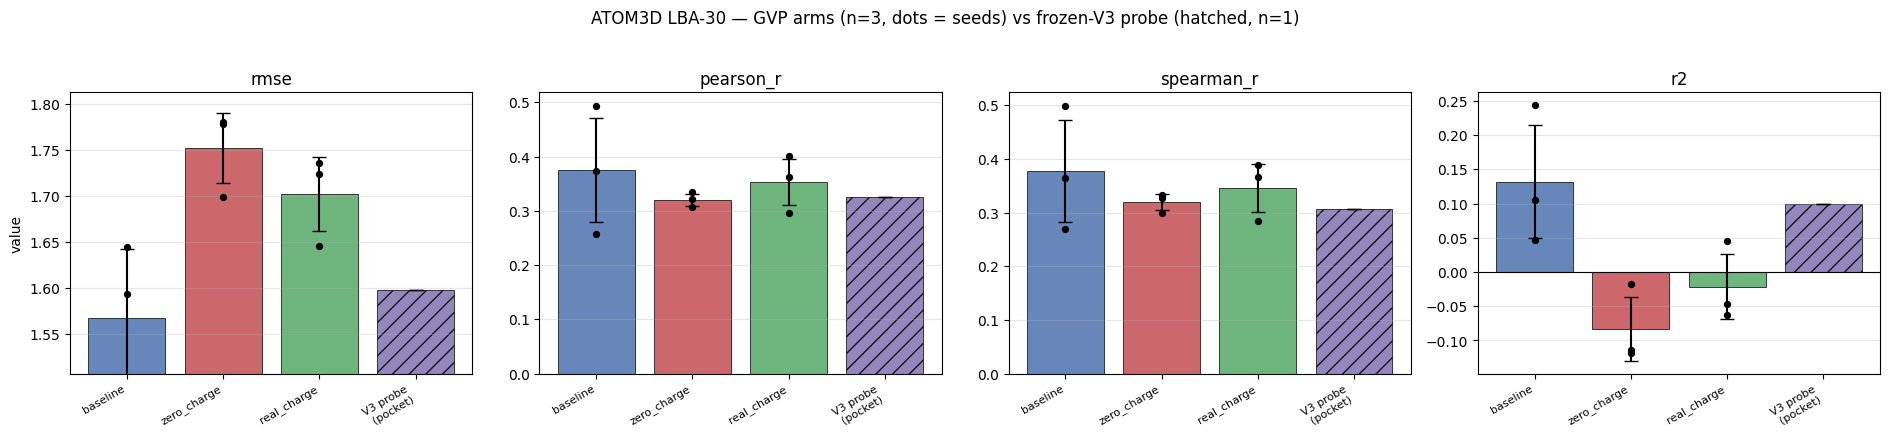

                     rmse  pearson_r  spearman_r      r2  n_seeds
model                                                            
baseline           1.5675     0.3750      0.3773  0.1319        3
zero_charge        1.7525     0.3208      0.3200 -0.0831        3
real_charge        1.7019     0.3531      0.3463 -0.0215        3
V3 probe (pocket)  1.5980     0.3247      0.3075  0.0998        1


In [9]:
# §4b — GVP arms alongside the frozen-V3 linear probe
# The probe is a SINGLE run (evaluate_proteinshake.py exposes no --seed), so it
# gets no error bar. Drawn hatched to make the n=1 vs n=3 distinction visible
# rather than implied.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# From results_atom3d_0.90_split/v3_atom3d_lba_{pocket,complex}_split0.90.json
# RMSE = sqrt(mse). Same 490-complex test set as the GVP runs (verified below).
PROBE = {
    "V3 probe\n(pocket)":  dict(mse=2.553701162338257, pearson_r=0.3246543025238221,
                                spearman_r=0.3075130234173158, r2=0.09980326890945435),
    
}
for v in PROBE.values():
    v["rmse"] = np.sqrt(v["mse"])

# Test-label variance is recoverable from every run as mse/(1-r2). If the probe
# and the GVP arms agree here, they were scored on the same labels and the
# numbers belong in one figure. Guard rather than assume.
var_probe = [v["mse"] / (1 - v["r2"]) for v in PROBE.values()]
gvp_row   = tests.iloc[0]
var_gvp   = gvp_row["rmse"] ** 2 / (1 - gvp_row["r2"])
print(f"label variance — probe: {[f'{v:.4f}' for v in var_probe]}  GVP: {var_gvp:.4f}")
assert all(abs(v - var_gvp) < 0.01 for v in var_probe), \
    "Label variance differs — probe and GVP arms are NOT on the same test set."

labels = list(summary.index) + list(PROBE.keys())
PROBE_COLOR = "#8172B2"

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, metric in zip(axes, METRICS):
    vals = list(summary[f"{metric}_mean"]) + [PROBE[k][metric] for k in PROBE]
    errs = list(summary[f"{metric}_std"])  + [0.0] * len(PROBE)
    cols = [COLORS[a] for a in summary.index] + [PROBE_COLOR] * len(PROBE)
    x = np.arange(len(vals))

    bars = ax.bar(x, vals, yerr=errs, capsize=5, color=cols, alpha=0.85,
                  edgecolor="black", linewidth=0.6)
    for b in bars[len(summary):]:
        b.set_hatch("//")

    for i, arm in enumerate(summary.index):
        pts = tests[tests.arm == arm][metric]
        ax.scatter(np.full(len(pts), i), pts, color="black", zorder=3, s=18)

    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_title(metric); ax.grid(axis="y", alpha=0.3)
    if metric == "r2":
        ax.axhline(0, color="black", lw=0.8)
    if metric == "rmse":
        lo, hi = min(vals) - 0.06, max(vals) + 0.06
        ax.set_ylim(lo, hi)          # a 0-anchored axis hides the whole effect

axes[0].set_ylabel("value")
fig.suptitle("ATOM3D LBA-30 — GVP arms (n=3, dots = seeds) vs frozen-V3 probe "
             "(hatched, n=1)", y=1.03)
plt.tight_layout(); plt.show()

comparison = pd.DataFrame(
    [{"model": a, **{m: summary.loc[a, f"{m}_mean"] for m in METRICS}, "n_seeds": 3}
     for a in summary.index] +
    [{"model": k.replace("\n", " "), **{m: PROBE[k][m] for m in METRICS}, "n_seeds": 1}
     for k in PROBE]).set_index("model").round(4)
print(comparison.to_string())

## §5 — Training curves

Train loss vs val loss per arm. The gap between them is the overfitting story,
and it is the mechanism already diagnosed for Option A: 128 frozen dimensions
add capacity without adding generalizable signal.

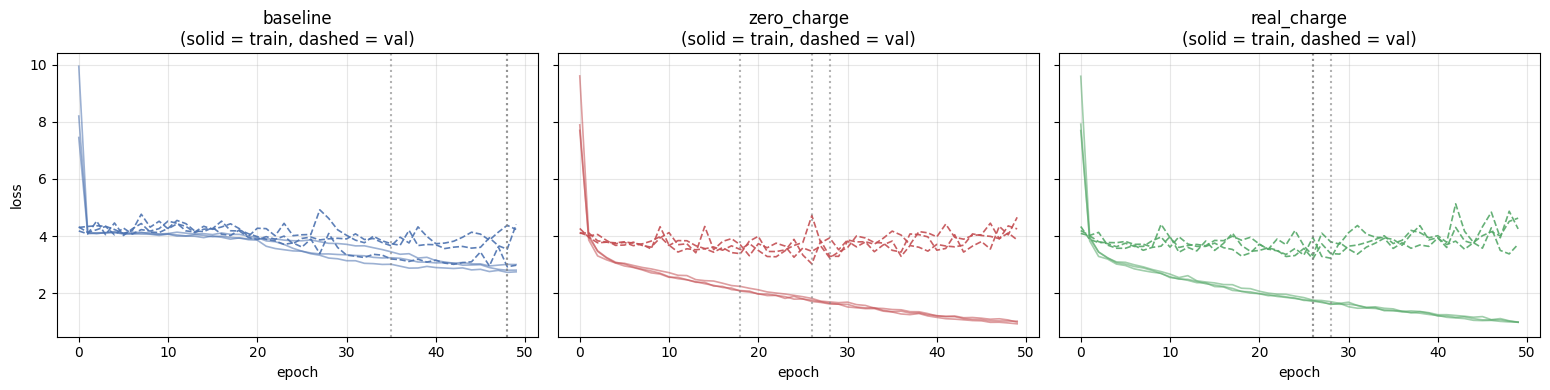

Best-val epoch per arm/seed (the effective early-stopping point):
        arm  seed  epoch     loss
   baseline     7     48 3.544516
   baseline    42     48 2.927974
   baseline   123     35 3.661132
real_charge     7     28 3.228406
real_charge    42     26 3.204690
real_charge   123     26 3.321426
zero_charge     7     18 3.388258
zero_charge    42     28 3.239922
zero_charge   123     26 3.031554

Final-epoch train loss vs best val loss (overfitting gap):
        arm  seed  final_train_loss  best_val_loss
   baseline    42             2.752          2.928
zero_charge    42             1.025          3.240
   baseline   123             3.007          3.661
zero_charge   123             0.932          3.032
   baseline     7             2.811          3.545
zero_charge     7             0.989          3.388
real_charge    42             0.984          3.205
real_charge   123             0.993          3.321
real_charge     7             0.992          3.228


In [5]:
# §5 — train/val loss curves, one panel per arm
arms_present = [a for a in ARM_ORDER if a in curves.arm.unique()]
fig, axes = plt.subplots(1, len(arms_present), figsize=(5.2 * len(arms_present), 4),
                         sharey=True, squeeze=False)

for ax, arm in zip(axes[0], arms_present):
    sub = curves[curves.arm == arm]
    for seed in sorted(sub.seed.unique()):
        s = sub[sub.seed == seed]
        ax.plot(s[s.split == "train"].epoch, s[s.split == "train"].loss,
                color=COLORS[arm], alpha=0.55, lw=1.2)
        ax.plot(s[s.split == "val"].epoch, s[s.split == "val"].loss,
                color=COLORS[arm], alpha=0.9, lw=1.2, ls="--")
    # Mark where each seed's best val loss occurred -- the effective stopping
    # point. Everything to the right of it is wasted or actively harmful.
    for seed in sorted(sub.seed.unique()):
        v = sub[(sub.seed == seed) & (sub.split == "val")]
        if len(v):
            best = v.loc[v.loss.idxmin()]
            ax.axvline(best.epoch, color="grey", ls=":", alpha=0.6)
    ax.set_title(f"{arm}\n(solid = train, dashed = val)")
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)

axes[0][0].set_ylabel("loss")
plt.tight_layout()
plt.show()

print("Best-val epoch per arm/seed (the effective early-stopping point):")
best_ep = (curves[curves.split == "val"]
           .loc[curves[curves.split == "val"].groupby(["arm", "seed"], observed=True).loss.idxmin()]
           [["arm", "seed", "epoch", "loss"]]
           .sort_values(["arm", "seed"]))
print(best_ep.to_string(index=False))
print("\nFinal-epoch train loss vs best val loss (overfitting gap):")
last_tr = (curves[(curves.split == "train") & (curves.epoch == curves.epoch.max())]
           [["arm", "seed", "loss"]].rename(columns={"loss": "final_train_loss"}))
print(last_tr.merge(best_ep[["arm", "seed", "loss"]].rename(columns={"loss": "best_val_loss"}),
                    on=["arm", "seed"]).round(3).to_string(index=False))

## §6 — Paper-ready table

In [6]:
# §6 — markdown table for the manuscript
rows = []
for arm in ARM_ORDER:
    if arm not in summary.index:
        continue
    r = summary.loc[arm]
    rows.append(f"| {arm} | {r['rmse_mean']:.3f} ± {r['rmse_std']:.3f} "
                f"| {r['pearson_r_mean']:.3f} ± {r['pearson_r_std']:.3f} "
                f"| {r['spearman_r_mean']:.3f} ± {r['spearman_r_std']:.3f} "
                f"| {r['r2_mean']:.3f} ± {r['r2_std']:.3f} |")

print("| Arm | RMSE | Pearson r | Spearman r | R² |")
print("|---|---|---|---|---|")
print("\n".join(rows))

d_rmse, t_rmse, p_rmse = paired("rmse", "zero_charge", "real_charge")
print(f"\nPaired A->C on RMSE: mean Δ = {d_rmse.mean():+.4f}, "
      f"t({len(d_rmse)-1}) = {t_rmse:.3f}, p = {p_rmse:.4f}")

| Arm | RMSE | Pearson r | Spearman r | R² |
|---|---|---|---|---|
| baseline | 1.567 ± 0.076 | 0.375 ± 0.096 | 0.377 ± 0.094 | 0.132 ± 0.083 |
| zero_charge | 1.752 ± 0.038 | 0.321 ± 0.011 | 0.320 ± 0.015 | -0.083 ± 0.046 |
| real_charge | 1.702 ± 0.040 | 0.353 ± 0.043 | 0.346 ± 0.045 | -0.021 ± 0.048 |

Paired A->C on RMSE: mean Δ = -0.0506, t(2) = -11.261, p = 0.0078


In [7]:
# Sketch: load cached (N,128) tensors, attention-pool, train a small head.
# Run once with charge_real, once with charge_zero, several seeds each.
import torch, glob, os
from atom3d.datasets import LMDBDataset

CACHE = "v3_lba_precomputed_cache/charge_real"   # then charge_zero
def load_split(split):
    ds = LMDBDataset(f"data/atom3D/split-by-sequence-identity-30/data/{split}")
    X, y = [], []
    for e in ds:
        p = f"{CACHE}/{split}/{e['id']}_pocket.pt"
        if os.path.exists(p):
            X.append(torch.load(p, weights_only=True))   # (N_pocket, 128)
            y.append(e['scores']['neglog_aff'])
    return X, torch.tensor(y)